# 6.10 The Schrödinger Equation as a PDE, Solved on a Computer

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VI — Quantum Mechanics",
    number="6.10",
    title="The Schrödinger Equation as a PDE, Solved on a Computer",
    blurb="Diagonalize, and you are done. The time-independent Schrödinger equation "
    "is an eigenvalue problem for a Hermitian operator, and on a grid that operator "
    "is a matrix — the kinetic energy a finite-difference stencil, the potential a "
    "diagonal. We hand it to the same routine that diagonalized every operator in "
    "Movement 0, check it against the square well's exact spectrum, and then solve "
    "potentials no formula can reach.",
    difficulty="advanced",
    estimate="160–195 min",
)

<ECP header: 2762 chars of HTML>

## Notebook overview

Volume VI has made one claim more than any other: quantum mechanics *is* linear algebra. In this
notebook that claim stops being a slogan and becomes a literal **method** for solving real, continuous
systems. The time-independent Schrödinger equation $\hat H\psi=E\psi$ is, word for word, the
eigenvalue problem of a Hermitian operator — the same problem we solved for a $2\times2$ spin operator
in [§6.2](operators-spectral-theorem.ipynb). The only new step is to write that operator as a matrix, and the position representation of
[§6.9](position-representation.ipynb) tells us exactly how: put $x$ on a grid, approximate the second derivative by a finite-difference
stencil, and the Schrödinger operator becomes a finite **matrix** we hand to `numpy.linalg.eigh`. Its
eigenvalues are the allowed energies; its eigenvectors are the stationary states.

The discipline of computational physics is to never trust a number you have not checked, so we begin
with the one problem that has a clean exact answer — the **infinite square well**, $E_n=n^2\pi^2\hbar^2
/2mL^2$ — and validate the method against it from three angles: the energies match to several digits,
the eigenfunctions match the analytic sines $\sqrt{2/L}\sin(n\pi x/L)$ to machine precision, and the
computed states are orthonormal (the `eigh` guarantee of [§6.2](operators-spectral-theorem.ipynb), now producing *wave functions*). We
then watch the energy error fall as $1/N^2$ with the grid resolution — the second-order accuracy of
the finite-difference stencil, the floating-point-and-discretization sensibility of Volume 0 in the
quantum setting — and are honest about where the method strains (the highest computed levels are
always the least trustworthy).

Then comes the payoff. Nothing in the recipe used the square well's analytic solution: it needs only
$V(x)$ on a grid. So the *same three lines* — build the kinetic stencil, add the diagonal potential,
diagonalize — solve **any** one-dimensional potential, including those with no closed form. We turn
them loose on an anharmonic well and read its spectrum straight off the screen. This is the engine
for the rest of Movement II: bound states ([§6.11](bound-states-1d.ipynb)), the harmonic oscillator ([§6.12](harmonic-oscillator.ipynb)), and — once we
restore the time dependence — wave packets in motion ([§6.13](scattering-tunneling.ipynb)).

As in every Volume VI notebook, each exercise opens with a **crystal-clear statement** and enumerated parts, each naming the exact operation — the $(1,-2,1)/dx^2$ second-difference stencil, `numpy.diag`
to assemble the tridiagonal kinetic matrix, and `numpy.linalg.eigh` (the symmetric/Hermitian solver,
returning *sorted* real eigenvalues and orthonormal eigenvectors).

> **Conventions.** We set $\hbar=1$ and $m=1$. The grid is the **interior** of $[0,L]$
> (or $[-L/2,L/2]$ for confining potentials): $N$ points with spacing $dx$, and the Dirichlet boundary
> condition $\psi=0$ at the walls is built in by leaving the boundary points off the grid (a confining
> $V$ instead needs a box large enough that $\psi$ has decayed). Eigenfunctions from `numpy.linalg.eigh`
> are normalized in the discrete sense; we divide by $\sqrt{dx}$ so that $\int|\psi|^2dx=1$. For large
> grids `scipy.linalg.eigh_tridiagonal` is the efficient specialized solver. See Griffiths and Sakurai
> & Napolitano (the square well); Giordano & Nakanishi (the matrix method); and Notebooks [§6.2](operators-spectral-theorem.ipynb) (`eigh`,
> the eigenvalue problem), [§6.7](time-evolution.ipynb) (stationary states), [§6.9](position-representation.ipynb) (the position representation), and Volume 0
> (finite differences, discretization error).

## Theory in brief

### The time-independent Schrödinger equation as an eigenproblem

Separating the time dependence (the stationary states $e^{-iEt/\hbar}$ of [§6.7](time-evolution.ipynb)) leaves the
**time-independent Schrödinger equation**, an eigenvalue problem for a Hermitian operator,

```{math}
:label: eq-tise
\hat H\psi=E\psi,\qquad \hat H=-\frac{\hbar^2}{2m}\frac{d^2}{dx^2}+V(x) .
```

Its eigenvalues are the allowed **energies** and its eigenfunctions the **stationary states**.
"Solving quantum mechanics" for a potential means diagonalizing this operator ([§6.2](operators-spectral-theorem.ipynb)).

### Discretizing the Hamiltonian into a matrix

Put $x$ on a grid of $N$ points with spacing $dx$. The second derivative becomes the
**finite-difference stencil**, a tridiagonal matrix,

```{math}
:label: eq-discretize
\psi''(x_i)\approx\frac{\psi_{i+1}-2\psi_i+\psi_{i-1}}{dx^2},\qquad \hat H\to H=-\frac{\hbar^2}{2m}\,\frac{1}{dx^2}\,\mathrm{tridiag}(1,-2,1)+\mathrm{diag}\,V(x_i) .
```

So $\hat H$ becomes a real **symmetric** matrix (Hermitian), and `numpy.linalg.eigh` returns its
sorted eigenvalues (the energies) and orthonormal eigenvectors (the stationary states, normalized by
dividing by $\sqrt{dx}$). The Dirichlet condition $\psi=0$ at hard walls is built in by restricting to
the interior grid.

### The infinite square well: the validation

For $V=0$ in $[0,L]$ with infinite walls, the exact spectrum and eigenfunctions are

```{math}
:label: eq-square-well
E_n=\frac{n^2\pi^2\hbar^2}{2mL^2},\qquad \psi_n(x)=\sqrt{\frac{2}{L}}\sin\frac{n\pi x}{L},\qquad n=1,2,\dots
```

The ground-state energy is **nonzero** — the zero-point energy: confinement forces motion, the
uncertainty principle of [§6.9](position-representation.ipynb) in action. We validate the numerics against all of this.

### Convergence and its limits

The finite-difference second derivative is **second-order** accurate, so the energy error falls as

```{math}
:label: eq-convergence
|E_n^{\text{num}}-E_n|\sim\frac{1}{N^2} .
```

Higher levels (more wiggly eigenfunctions) need more points per wavelength and converge later — the
highest computed eigenvalues are always the least trustworthy, a resolution diagnostic to state
honestly.

### The general method

Nothing in the recipe used the analytic solution — it needs only $V(x)$ on a grid,

```{math}
:label: eq-general
\text{any } V(x)\ \xrightarrow{\ \text{stencil}+\mathrm{diag}\,V+\texttt{eigh}\ }\ \{E_n,\psi_n\} ,
```

so the same three steps solve **any** one-dimensional potential, including those with no closed form.
This is the payoff: the computer solves problems pencil-and-paper cannot.

## Setup

Data and instruments only: the series palette, the unit conventions $\hbar=m=1$, and
`plot_levels`, the plotting scaffold that draws the standard textbook spectrum picture — each
eigenfunction ribboned at its own energy above the potential. The two objects this notebook is
named for are deliberately absent: you assemble the discretized Hamiltonian yourself in
Exercise 1 and write the diagonalization that turns it into energies and stationary states in
Exercise 2, and every later exercise calls the ones you wrote.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from ecp import draw, validate

ACCENT, INK, SOFT = draw.ACCENT, draw.INK, draw.SOFT  # data: the series palette

# data: the unit conventions of this notebook
HBAR = 1.0  # ℏ = 1
MASS = 1.0  # m = 1

# Conventions: the grid is always the INTERIOR of the box, so the Dirichlet condition ψ=0 at the hard
# walls is built in by leaving the boundary points off the grid. numpy.linalg.eigh returns SORTED real
# eigenvalues (energies) and orthonormal eigenvectors (stationary states); dividing the eigenvectors by
# √dx makes ∫|ψ|²dx = 1. (scipy.linalg.eigh_tridiagonal is the efficient option for large grids.)


# instrument: a plotting scaffold, not the lesson — it arranges energies and states that Exercises 1
# and 2 produce into the familiar level diagram; the physics is in the numbers it is handed.
def plot_levels(ax, x, V, energies, states, n_levels=4, scale=None):
    """Plot the potential with energy levels and eigenfunctions drawn at their energies — a plotting helper.

    Draws $V(x)$, a horizontal line at each $E_n$, and the eigenfunction $\\psi_n(x)$ scaled and offset
    to sit at height $E_n$ — the standard textbook picture of a spectrum.
    """
    ax.plot(x, V, color=INK, lw=1.8, zorder=3)
    if scale is None:
        gaps = np.diff(energies[: n_levels + 1])
        scale = 0.5 * np.median(gaps) / np.max(np.abs(states[:, 0]))
    for n in range(n_levels):
        ax.axhline(energies[n], color=SOFT, lw=0.8, ls=":", zorder=1)
        psi = states[:, n]
        if np.trapezoid(psi, x) < 0:
            psi = -psi
        ax.plot(x, energies[n] + scale * psi, color=ACCENT, lw=1.6, zorder=2)

## Exercise 1 — Building the Hamiltonian matrix

Everything in this notebook rests on a single translation: once $x$ lives on a grid, the
Schrödinger operator $\hat H=-\tfrac{\hbar^2}{2m}\tfrac{d^2}{dx^2}+V(x)$ *is* a matrix
{eq}`eq-tise`, {eq}`eq-discretize`. The second derivative becomes the $(1,-2,1)/dx^2$
second-difference stencil — a tridiagonal matrix — and the potential becomes the diagonal
$\mathrm{diag}\,V(x_i)$, so
$H=-\tfrac{\hbar^2}{2m}\tfrac{1}{dx^2}\,\mathrm{tridiag}(1,-2,1)+\mathrm{diag}\,V$. Both pieces are
real and symmetric, which is exactly what makes $H$ Hermitian and licenses handing it to the
Hermitian eigensolver of [§6.2](operators-spectral-theorem.ipynb).

1. Write `hamiltonian(x, V)`, returning $H$ for a grid `x` and a potential `V` sampled on it: the
   kinetic term is $-\hbar^2/2m$ times the $(1,-2,1)/dx^2$ stencil assembled with `numpy.diag`
   ($-2$ on the main diagonal, $1$ on the two off-diagonals), and the potential enters as
   `numpy.diag(V)`. **Write this one yourself** — the implementation is the lesson.
2. Set up the interior grid for the square well ($N$ points on $[0,L]$ with the two boundary points
   left off, which imposes $\psi=0$ at the walls) with $V=0$ inside, and assemble $H$ on it.
3. Confirm $H$ is real (`numpy.isreal`) and symmetric ($H=H^{\mathsf T}$, `numpy.allclose(H,
   H.T)`) — a Hermitian operator. The Schrödinger operator is a matrix.

In [3]:
# (solution hidden on the public site)


H shape (400, 400), real True, symmetric H = Hᵀ True
diagonal entries = −ℏ²/2m · (−2/dx²) + V = 160801.00;  off-diagonal = −ℏ²/2m · (1/dx²) = -80400.50


### Validation 1

In [4]:
validate.check(
    is_real and is_symmetric and np.isclose(H[0, 1], -(HBAR**2 / (2 * MASS)) / dx**2),
    "the discretized Hamiltonian is a real symmetric (Hermitian) matrix: −(ℏ²/2m)·(1,−2,1)/dx² stencil plus diag(V)",
)

✓  the discretized Hamiltonian is a real symmetric (Hermitian) matrix: −(ℏ²/2m)·(1,−2,1)/dx² stencil plus diag(V)


True

## Exercise 2 — The infinite square well spectrum

Never trust a number you have not checked, so the method's first outing is on the one problem with
a classroom-exact answer: for $V=0$ between infinite walls the spectrum is
$E_n=n^2\pi^2\hbar^2/2mL^2$ {eq}`eq-square-well`. Everything the rest of the notebook does rests on
this validation against an exact answer. Two features are worth watching. The ground state has
$E_1>0$ — the **zero-point energy**: a confined particle cannot be at rest, the uncertainty
principle of [§6.9](position-representation.ipynb) in action. And the relative errors grow with $n$,
because a wigglier eigenfunction gets fewer grid points per wavelength; Exercise 4 makes that
quantitative.

1. Write `solve(x, V)`: assemble $H$ with the `hamiltonian` you wrote in Exercise 1, diagonalize it
   with `numpy.linalg.eigh` — the Hermitian solver of [§6.2](operators-spectral-theorem.ipynb),
   which returns *sorted* real eigenvalues and orthonormal eigenvectors — and divide the
   eigenvector columns by $\sqrt{dx}$ so each stationary state has $\int|\psi_n|^2dx=1$. Return the
   energies and the states.
2. Run it on the square well of Exercise 1 ($V=0$ on the interior grid) and take the lowest five
   eigenvalues.
3. Compare to $E_n=n^2\pi^2\hbar^2/2mL^2$ for $n=1,\dots,5$ and report the relative errors.
4. Report the ground-state energy and confirm $E_1>0$.

In [5]:
# (solution hidden on the public site)


n   E_numeric    E_exact      rel. error
1     4.93478     4.93480    5.11e-06
2    19.73880    19.73921    2.05e-05
3    44.41118    44.41322    4.60e-05
4    78.95037    78.95684    8.18e-05
5   123.35428   123.37006    1.28e-04

ground-state energy E_1 = 4.93478 > 0  (zero-point energy: confinement forces motion)


### Validation 2

In [6]:
validate.close(
    energies[:5],
    exact,
    "the infinite square well spectrum is Eₙ = n²π²ℏ²/2mL² (validated against the exact answer)",
    rtol=1e-3,
)

✓  the infinite square well spectrum is Eₙ = n²π²ℏ²/2mL² (validated against the exact answer)   [max|Δ| = 0.0157746 (rtol=0.001, atol=1e-09)]


True

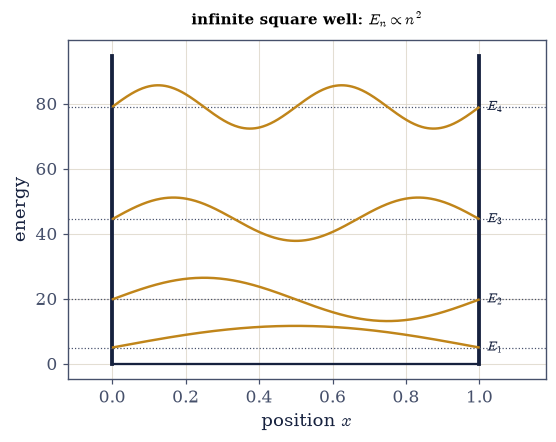

In [7]:
# (solution hidden on the public site)


## Exercise 3 — The eigenfunctions

The columns `eigh` returned are not merely numbers that pass a test: they are the **stationary
states** themselves, and for the square well their closed form is known,
$\psi_n(x)=\sqrt{2/L}\sin(n\pi x/L)$ {eq}`eq-square-well`. An eigenvector is defined only up to a
global sign, and a solver may return either, so a comparison against the analytic form has to fix
that convention before it means anything. Beyond matching the sines, the states inherit the `eigh`
orthonormality of [§6.2](operators-spectral-theorem.ipynb), $\langle\psi_i|\psi_j\rangle=
\delta_{ij}$ — the same guarantee that held for spin vectors there, now producing wave functions.

1. Extract $\psi_n(x)$ from the output of the `solve` you wrote in Exercise 2 (already normalized
   by $\sqrt{dx}$).
2. Fix the sign convention: flip so the overlap with the analytic form is positive.
3. Compare to $\sqrt{2/L}\sin(n\pi x/L)$ with `numpy.max(numpy.abs(...))`.
4. Verify orthonormality — the discrete inner product `(states.T @ states)·dx` is the identity to
   machine precision.

In [8]:
# (solution hidden on the public site)


max|ψ_numeric − ψ_analytic| for n=1,2,3:  6.57e-13  (machine precision)
orthonormality max|⟨ψ_i|ψ_j⟩ − δ_ij|:  1.78e-15  (the eigh guarantee, now wave functions)


### Validation 3

In [9]:
validate.close(
    [max(psi_errors), orthonormality_error],
    [0.0, 0.0],
    "the eigenfunctions are √(2/L)sin(nπx/L) and orthonormal (⟨ψ_i|ψ_j⟩=δ_ij to machine precision)",
    atol=1e-9,
)

✓  the eigenfunctions are √(2/L)sin(nπx/L) and orthonormal (⟨ψ_i|ψ_j⟩=δ_ij to machine precision)   [max|Δ| = 6.5728e-13 (rtol=1e-06, atol=1e-09)]


True

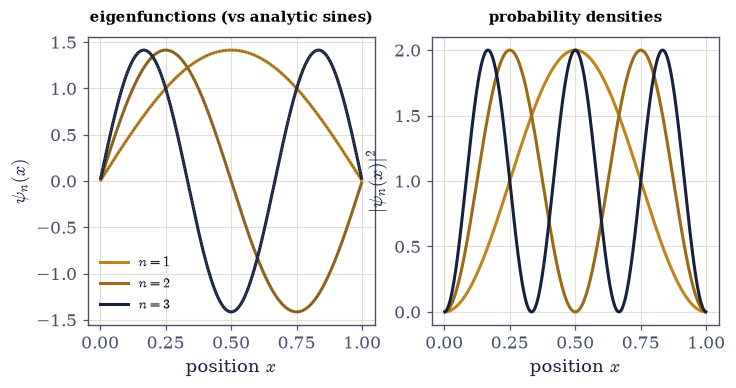

In [10]:
# (solution hidden on the public site)


## Exercise 4 — Convergence with grid resolution

The finite-difference second derivative is **second-order** accurate, so the energy error should
fall as $1/N^2$ with the number of grid points {eq}`eq-convergence`: a slope of $-2$ on log–log
axes, a fourfold gain for every doubling of the resolution. That is what makes the error
respectable rather than mysterious — it is discretization error, controllable and predictable,
exactly the sensibility of Volume 0 in quantum dress. Higher levels ride above the line and
converge later, since the wigglier the eigenfunction the more grid points per wavelength it needs;
the highest computed eigenvalue is always the least trustworthy.

1. Solve the square well for $N=25,50,100,\dots,800$ with the `solve` you wrote in Exercise 2.
2. Compute the relative error of the ground-state energy $E_1$ against the exact
   $\pi^2\hbar^2/2mL^2$.
3. Plot the error versus $N$ on log–log axes and confirm the slope is $-2$ (a $1/N^2$ reference
   line).

In [11]:
# (solution hidden on the public site)


N      relative error of E_1
  25   1.22e-03
  50   3.16e-04
 100   8.06e-05
 200   2.04e-05
 400   5.11e-06
 800   1.28e-06

log–log slope = -1.980  (≈ −2: second-order convergence, error ~ 1/N²)


### Validation 4

In [12]:
validate.close(
    slope,
    -2.0,
    "the finite-difference method converges at second order: the ground-state energy error scales as ~1/N²",
    atol=0.1,
)

✓  the finite-difference method converges at second order: the ground-state energy error scales as ~1/N²   [got -1.97953 vs expected -2 (rtol=1e-06, atol=0.1)]


True

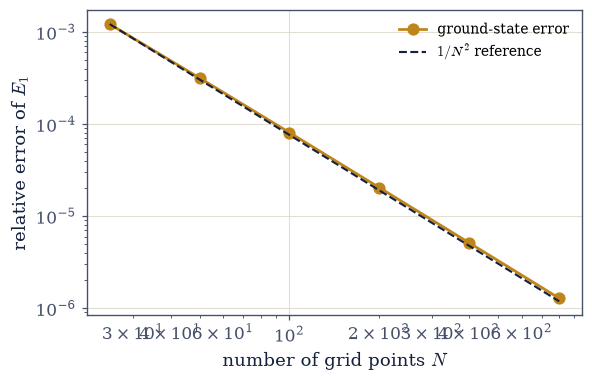

In [13]:
# (solution hidden on the public site)


## Exercise 5 — A potential with no closed form

Nothing in the recipe used the square well's analytic solution — it needs only $V(x)$ sampled on a
grid {eq}`eq-general`, so the same three steps solve potentials with no closed form at all, which
is to say the overwhelming majority of them. The anharmonic well $V(x)=\tfrac12x^2+\lambda x^4$ is
one such potential, and it wears its anharmonicity where the spectrum can be read: the quartic
term steepens the walls, squeezing the higher states upward, so the level spacings
$E_{n+1}-E_n$ *increase* with $n$ instead of staying equal as a harmonic oscillator's would. The
one precaution a confining potential demands is a box wide enough that the states of interest have
decayed before the hard walls.

1. Choose $V(x)=\tfrac12x^2+\lambda x^4$ on a box $[-L/2,L/2]$ large enough that the low-lying
   wave functions decay to zero at the edges.
2. Build $H$ and diagonalize with the same `solve` you wrote in Exercise 2 — *nothing* about the
   recipe changes.
3. Report the lowest five energies.
4. Confirm the level spacings $E_{n+1}-E_n$ increase with $n$, an anharmonicity no two-term formula
   captures. The method needs only $V(x)$; the computer solves the unsolvable.

In [14]:
# (solution hidden on the public site)


anharmonic well V = ½x² + 0.3x⁴, lowest five energies:
  [0.638  2.0945 3.8443 5.7954 7.9095]
  level spacings E_{n+1}−E_n = [1.4565 1.7498 1.9511 2.1142]
  (a harmonic oscillator would give equal spacings of 1; here they grow — anharmonicity)


### Validation 5

In [15]:
gram_anh = (psi_anh[:, :5].T @ psi_anh[:, :5]) * (x_anh[1] - x_anh[0])
validate.check(
    np.all(np.diff(spacings) > 0) and np.allclose(gram_anh, np.eye(5), atol=1e-9),
    "the finite-difference eigenmethod solves an arbitrary potential: the anharmonic well has growing level spacings and orthonormal eigenfunctions",
)

✓  the finite-difference eigenmethod solves an arbitrary potential: the anharmonic well has growing level spacings and orthonormal eigenfunctions


True

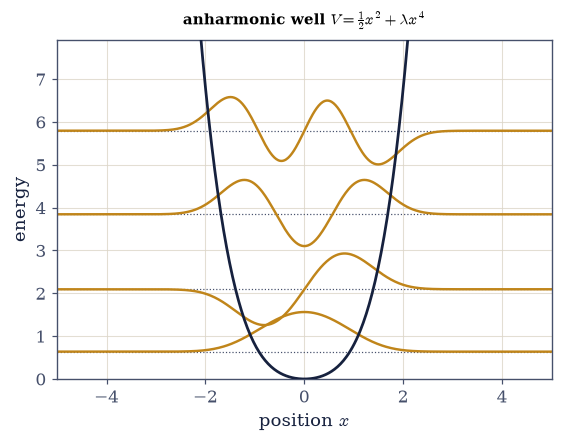

In [16]:
# (solution hidden on the public site)


## Exercise 6 — Resolution, box size, and trusting the answer *(student)*

A computed eigenvalue is only as good as its grid and its box {eq}`eq-convergence`,
{eq}`eq-general`, and for a confining potential the two err in different directions. Too small a
box adds artificial confinement — the hard walls squeeze the state and push its energy *up* — while
too coarse a grid fails to resolve the wave function's wiggles. The harmonic oscillator
$V=\tfrac12x^2$ is the honest test bed for both, since its exact spectrum $E_n=n+\tfrac12$ is known
and each error can be watched shrinking against it.

1. Solve $V=\tfrac12x^2$ at several box sizes $L$ (with the grid fine enough) with the `solve` you
   wrote in Exercise 2, and read the ground-state energy.
2. Show that *too small* a box raises the energy and that it converges to $\tfrac12$ as $L$ grows.
3. Separately, show that *too coarse* a grid (small $N$) also errs, converging as $N$ grows.
4. State the rule of thumb: the box must contain the wave function's decay, and the grid must
   resolve its wiggles (points per wavelength). The computational-physics discipline is to trust an
   eigenvalue only inside its converged window.

In [17]:
# (solution hidden on the public site)


box size L (fixed dx≈0.02):  E_1 → ½
  L =    3:  E_1 = 0.67794   (error 1.8e-01)
  L =    5:  E_1 = 0.50451   (error 4.5e-03)
  L =    8:  E_1 = 0.49999   (error 1.2e-05)


  L =   14:  E_1 = 0.49999   (error 1.3e-05)
grid points N (fixed box L=14):  E_1 → ½
  N =   50:  E_1 = 0.49744   (error 2.6e-03)
  N =  100:  E_1 = 0.49937   (error 6.3e-04)
  N =  300:  E_1 = 0.49993   (error 6.9e-05)
  N =  700:  E_1 = 0.49999   (error 1.3e-05)


converged (L=16, N=800): E_1..E_4 = [0.5    1.4999 2.4998 3.4997]  vs exact n+½ = [0.5, 1.5, 2.5, 3.5]


### Validation 6

In [18]:
validate.close(
    E_conv[:4],
    np.array([0.5, 1.5, 2.5, 3.5]),
    "a trustworthy eigenvalue requires an adequate box and grid: with both converged, the harmonic oscillator gives Eₙ = n + ½",
    atol=1e-2,
)

✓  a trustworthy eigenvalue requires an adequate box and grid: with both converged, the harmonic oscillator gives Eₙ = n + ½   [max|Δ| = 0.000313311 (rtol=1e-06, atol=0.01)]


True

## Exercise 7 — Wave mechanics is a matrix eigenvalue problem *(synthesis)*

The time-independent Schrödinger equation is the eigenvalue problem of a Hermitian operator, and on a
grid that operator is a **matrix** we already knew how to diagonalize. We checked the recipe against
the square well's exact spectrum — energies to several digits, eigenfunctions to machine precision,
orthonormality from `eigh` — watched the error fall as $1/N^2$, and then solved a potential no formula
can reach, all with the *same three lines* that diagonalized a $2\times2$ spin operator in Movement 0:
build the kinetic stencil, add the diagonal potential, call `numpy.linalg.eigh`. This is the engine of
computational quantum mechanics: give it a potential, get its spectrum and its stationary states.

There is no new computation to do here; the method *is* the result. And there is a quiet triumph
in it. The equation that took Schrödinger a winter to solve for hydrogen, we solve for an
arbitrary potential in a few lines — not because we are cleverer, but because diagonalizing a matrix
is something a computer does without thinking. The next notebooks apply this engine to real
bound-state problems and parity ([§6.11](bound-states-1d.ipynb)) and to the harmonic oscillator's analytic and algebraic
solutions checked against the grid ([§6.12](harmonic-oscillator.ipynb)); and once we restore the time dependence, to wave packets in
motion ([§6.13](scattering-tunneling.ipynb)). The arena is the continuum now, but the method has not changed since [§6.2](operators-spectral-theorem.ipynb) — *diagonalize*.

## Notebook summary

The Schrödinger equation solved by the diagonalization method of Movement 0 — the engine of
computational quantum mechanics.

- **The eigenproblem** {eq}`eq-tise`: $\hat H\psi=E\psi$ with $\hat H=-\tfrac{\hbar^2}{2m}\tfrac{d^2}
  {dx^2}+V$ — the Hermitian eigenvalue problem of [§6.2](operators-spectral-theorem.ipynb), now for a continuous system.
- **Discretization** {eq}`eq-discretize`: the $(1,-2,1)/dx^2$ stencil (`numpy.diag`) makes the kinetic
  term tridiagonal and $V$ diagonal, so $\hat H\to$ a real symmetric matrix for `numpy.linalg.eigh`
  (`scipy.linalg.eigh_tridiagonal` for speed).
- **The square-well validation** {eq}`eq-square-well`: energies $E_n=n^2\pi^2\hbar^2/2mL^2$ to several
  digits, eigenfunctions $\sqrt{2/L}\sin(n\pi x/L)$ to machine precision, orthonormal; a nonzero
  zero-point energy.
- **Convergence** {eq}`eq-convergence`: second-order, error $\sim1/N^2$ (slope $-2$ on log–log);
  higher levels converge later — the highest are least trustworthy.
- **The general method** {eq}`eq-general`: the recipe needs only $V(x)$, so it solves any 1-D potential
  — demonstrated on an anharmonic well with growing level spacings.

Solving the Schrödinger equation is diagonalization. The arena changed from two amplitudes to a
continuum; the method did not change at all.

## Outlook

- **Bound states in one dimension ([§6.11](bound-states-1d.ipynb))**: finite wells, parity, bound-state counting, the double
  well.
- **The harmonic oscillator ([§6.12](harmonic-oscillator.ipynb))**: the analytic and algebraic (ladder-operator) solutions, checked
  against the grid; coherent states.
- **Time evolution on the grid ([§6.13](scattering-tunneling.ipynb))**: split-step Fourier and Crank–Nicolson for wave-packet
  dynamics.
- **Three dimensions and central potentials ([§6.16](central-potentials-3d.ipynb)–[§6.17](hydrogen-atom.ipynb))**: separate variables and solve the radial
  equation the same way.
- **Cross-reference** [§6.2](operators-spectral-theorem.ipynb) (`eigh`, the eigenvalue problem), [§6.7](time-evolution.ipynb) (stationary states), [§6.9](position-representation.ipynb) (the position
  representation), Volume 0 (finite differences, discretization error), and forward to [§6.11](bound-states-1d.ipynb), [§6.12](harmonic-oscillator.ipynb),
  [§6.13](scattering-tunneling.ipynb).

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>